# What your data can and cannot tell you about execution

Prediction-market research usually runs on periodic book snapshots, because
that is what the public APIs give you. Snapshots support some execution claims
and not others, and the difference is not a matter of degree: a queue-position
fill needs every delta between snapshots, and no amount of care recovers it
from a five-minute grid. This recipe computes the microstructure signals a
snapshot *does* support, watches preflight refuse the one it does not, and
prices the size you can actually trade.

## Terms used here

| term           | meaning |
| -------------- | --- |
| snapshot data  | the book sampled on a grid, which is what public APIs give you |
| delta data     | every individual book change, which snapshots cannot be turned back into |
| depth          | the size resting at each price level, and so the size you can actually trade |
| microprice     | the mid weighted by size on each side, a better estimate of where price is going |
| imbalance      | bid size relative to ask size at the top of book |
| queue position | where your order sits in the line at its price level; it needs delta data |
| preflight      | a check that rejects a claim the data cannot support, before the run starts |
| fill ratio     | the fraction of your intended quantity that actually executed |
| cost budget    | the total costs a strategy must clear before it makes anything |

New to any of these? [GLOSSARY.md](../../GLOSSARY.md) defines them at more
length, along with every other term the cookbook uses.

In [1]:
import datetime as dt

import matplotlib.pyplot as plt
import pandas as pd

import cookbook_utils as cu
import h5i_db
from h5i_db import backtest

db = h5i_db.Database(cu.fresh_db("05_execution_fidelity_and_depth"), create=True)
FEE_RATE = 0.07

## The panel

Periodic full-book snapshots, one level each side, with depth that varies
through the session. `size` is the column this recipe leans on: it is what
decides how much you can trade and what a microprice means.

| column | type | meaning |
|---|---|---|
| `ts_init` | `timestamp[ns]` | recorder arrival; replay order |
| `instrument_id` | `string` | the market |
| `outcome` | `uint16` | 0 = YES, 1 = NO |
| `action` | `string` | `snapshot`; a real feed also carries `delta` and gaps |
| `side` | `string` | `buy` is the bid, `sell` the ask |
| `price` | `float64` | probability on a 0.001 grid |
| `size` | `float64` | contracts displayed at that level |

In [2]:
panel = cu.make_prediction_markets(n_markets=60, steps=32, seed=11)
for name, table in panel.items():
    db.create_table(name, table.schema, time_column="ts_init")
    db.append(name, table, note="panel load")
db.snapshot("panel-v1", tables=list(panel), note="execution study input")
print(f"{panel['book_deltas'].num_rows:,} book rows across {panel['resolutions'].num_rows} markets")
panel["book_deltas"].to_pandas().head()

8,640 book rows across 60 markets


,ts_init,ts_event,instrument_id,outcome,action,side,price,size,event_index,is_last,source_vendor
0,2026-05-01 12:00:00,2026-05-01 12:00:00,EVENT-0000,0,snapshot,buy,0.087,89.826,1,False,cookbook-sim
1,2026-05-01 12:00:00,2026-05-01 12:00:00,EVENT-0000,0,snapshot,sell,0.103,61.859,1,True,cookbook-sim
2,2026-05-01 12:00:00,2026-05-01 12:00:00,EVENT-0000,1,snapshot,buy,0.884,57.380,2,False,cookbook-sim
3,2026-05-01 12:00:00,2026-05-01 12:00:00,EVENT-0000,1,snapshot,sell,0.900,100.910,2,True,cookbook-sim
4,2026-05-01 12:00:00,2026-05-01 12:00:00,EVENT-0001,0,snapshot,buy,0.100,121.779,3,False,cookbook-sim


## Signals a snapshot supports

The microprice weights each side by the *opposite* side's size, so it leans
toward the side with less resting liquidity. Imbalance is the same information
on a bounded scale. Both are computable from one snapshot, which is exactly why
they are the honest choice for snapshot data.

In [3]:
expiry_ns = int(db.sql("SELECT max(expiration_ns) AS e FROM instruments").to_pandas()["e"][0])
tops = db.sql(
    f"""
    SELECT ts_init AS ts, instrument_id,
           max(CASE WHEN side = 'buy'  THEN price END) AS bid,
           max(CASE WHEN side = 'sell' THEN price END) AS ask,
           max(CASE WHEN side = 'buy'  THEN size  END) AS bid_size,
           max(CASE WHEN side = 'sell' THEN size  END) AS ask_size
    FROM h5i('book_deltas', 'panel-v1')
    WHERE outcome = 0 AND ts_init <= to_timestamp_nanos({expiry_ns})
    GROUP BY ts_init, instrument_id
    ORDER BY ts_init, instrument_id
    """
).to_pandas()
tops["mid"] = (tops.bid + tops.ask) / 2
tops["microprice"] = (tops.bid * tops.ask_size + tops.ask * tops.bid_size) / (
    tops.bid_size + tops.ask_size
)
tops["imbalance"] = (tops.bid_size - tops.ask_size) / (tops.bid_size + tops.ask_size)
tops["lean_bp"] = (tops.microprice - tops.mid) * 10_000
tops["spread_bp"] = (tops.ask - tops.bid) * 10_000
print(f"{len(tops):,} snapshots")
print(tops[["bid", "ask", "mid", "microprice", "imbalance", "lean_bp", "spread_bp"]].describe().round(3).to_string())

1,920 snapshots
            bid       ask       mid  microprice  imbalance   lean_bp  spread_bp
count  1920.000  1920.000  1920.000    1920.000   1920.000  1920.000   1920.000
mean      0.493     0.505     0.499       0.499     -0.001    -0.032    120.333
std       0.233     0.233     0.233       0.233      0.180    10.958     24.208
min       0.075     0.091     0.083       0.082     -0.404   -30.961     80.000
25%       0.287     0.299     0.293       0.293     -0.118    -6.856    100.000
50%       0.496     0.504     0.500       0.501     -0.004    -0.251    120.000
75%       0.696     0.708     0.702       0.702      0.114     7.051    140.000
max       0.896     0.912     0.904       0.906      0.404    31.974    160.000


The spread widens at the tails, which is the shape real event books have: a
contract at 3 cents cannot be quoted a tick wide on both sides. Any signal
measured in absolute probability is therefore competing with a cost that varies
by price level.

In [4]:
tops["level"] = tops.mid.round(1).clip(0.1, 0.9)
by_level = tops.groupby("level").agg(
    snapshots=("mid", "size"),
    spread_bp=("spread_bp", "mean"),
    abs_lean_bp=("lean_bp", lambda s: s.abs().mean()),
    depth=("bid_size", "mean"),
)
print(by_level.round(1).to_string())

       snapshots  spread_bp  abs_lean_bp  depth
level                                          
0.1          112      160.0         12.3  105.8
0.2          253      140.2          9.0  112.1
0.3          260      120.0          8.5  108.9
0.4          232      100.0          7.5  109.3
0.5          230       80.0          6.0  105.7
0.6          233       99.9          7.1  110.1
0.7          237      120.0          8.6  110.7
0.8          249      140.2          9.8  108.1
0.9          114      160.0         10.7  114.0


## The claim preflight will not let you make

`queue_position=True` asks the engine to model where in the queue a resting
order sat. That requires the ordered deltas between snapshots. This panel has
periodic snapshots, so `backtest.inspect` refuses the config rather than
returning a plausible number.

In [5]:
submit_at = sorted({value.as_py() for value in panel["book_deltas"].column("ts_init")})[8]
signals = backtest.signal_table(
    [
        {
            "ts": submit_at + dt.timedelta(microseconds=1),
            "instrument_id": "EVENT-0030",
            "outcome": 0,
            "side": "buy",
            "quantity": 25.0,
            "tag": "probe",
        }
    ]
)
backtest.create_signal_table(db, "signals")
db.append("signals", signals)


def config(run_id: str, **execution) -> backtest.BacktestConfig:
    return backtest.BacktestConfig(
        run_id=run_id,
        data=backtest.DataConfig(signals="signals", snapshot="panel-v1"),
        portfolio=backtest.PortfolioConfig(starting_cash=100_000.0),
        execution=backtest.ExecutionConfig(fee_kind="kalshi", fee_rate=FEE_RATE, **execution),
        metadata={"study": "execution-fidelity"},
    )


queue_claim = backtest.inspect(db, config("queue-probe", queue_position=True))
print(f"ok: {queue_claim.ok}")
print(f"fidelity: {queue_claim.fidelity}")
for issue in queue_claim.errors:
    print(f"  error   {issue.code}: {issue.message}")
for issue in queue_claim.warnings:
    print(f"  warning {issue.code}: {issue.message}")

ok: False
fidelity: ReplayFidelity.SNAPSHOT_L2
  error   unsupported_queue_claim: queue-position replay is not defensible with snapshot_l2 inputs
  warning snapshot_only: periodic snapshots cannot reconstruct queue transitions between events


`execute` refuses it too, so the check cannot be skipped by not calling
`inspect`. That is the useful direction for a gate to fail in.

In [6]:
try:
    backtest.execute(db, config("queue-probe", queue_position=True))
except ValueError as error:
    print(f"execute refused: {error}")

execute refused: backtest preflight failed: unsupported_queue_claim: queue-position replay is not defensible with snapshot_l2 inputs


## What the data does support

Without the queue claim the config passes, and the inspection reports the
fidelity it *does* have. `snapshot_l2` with a `snapshot_only` warning is an
honest label: market orders against a known book are fine, queue mechanics are
not.

In [7]:
accepted = backtest.inspect(db, config("baseline"))
print(f"ok: {accepted.ok}  fidelity: {accepted.fidelity}")
for issue in accepted.warnings:
    print(f"  warning {issue.code}: {issue.message}")
baseline = backtest.execute(db, config("baseline"))
print(f"\nfilled at: {baseline.fills.to_pandas().price.iloc[0]:.4f}")
print(f"explain:   {baseline.explain()['fidelity']}, {baseline.explain()['status_counts']}")

ok: True  fidelity: ReplayFidelity.SNAPSHOT_L2
  warning snapshot_only: periodic snapshots cannot reconstruct queue transitions between events



filled at: 0.5160
explain:   snapshot_l2, {'filled': 1}


## Size is the binding constraint

One level per side means the displayed depth is the whole book. An order larger
than the top level cannot fill from a snapshot, and the engine says so rather
than inventing liquidity. Sweeping order size against the depth actually present
at the decision instant is a two-minute check that saves a fictional backtest.

In [8]:
target = tops[(tops.ts == submit_at) & (tops.instrument_id == "EVENT-0030")].iloc[0]
print(f"EVENT-0030 at {submit_at}: ask {target.ask:.3f} for {target.ask_size:.1f} contracts")

rows = []
for quantity in (10.0, 25.0, 100.0, 250.0, 600.0):
    name = f"size-{int(quantity)}"
    table = backtest.signal_table(
        [
            {
                "ts": submit_at + dt.timedelta(microseconds=1),
                "instrument_id": "EVENT-0030",
                "outcome": 0,
                "side": "buy",
                "quantity": quantity,
                "tag": name,
            }
        ]
    )
    db.create_table(f"signals_{name}", table.schema, time_column="ts")
    db.append(f"signals_{name}", table)
    result = backtest.execute(
        db,
        backtest.BacktestConfig(
            run_id=name,
            data=backtest.DataConfig(signals=f"signals_{name}", snapshot="panel-v1"),
            portfolio=backtest.PortfolioConfig(starting_cash=1_000_000.0),
            execution=backtest.ExecutionConfig(fee_kind="kalshi", fee_rate=FEE_RATE),
        ),
    )
    fills = result.fills.to_pandas()
    orders = result.orders.to_pandas()
    rows.append(
        {
            "requested": quantity,
            "filled": float(orders.filled.sum()),
            "status": orders.status.iloc[0],
            "avg_price": float((fills.price * fills.quantity).sum() / fills.quantity.sum())
            if len(fills)
            else float("nan"),
            "sweeps": result.explain()["orders_sweeping_multiple_levels"],
        }
    )
depth = pd.DataFrame(rows)
depth["fill_ratio"] = depth.filled / depth.requested
print(depth.round(3).to_string(index=False))

EVENT-0030 at 2026-05-01 14:00:00: ask 0.516 for 73.9 contracts


 requested  filled    status  avg_price  sweeps  fill_ratio
      10.0  10.000    filled      0.516       0       1.000
      25.0  25.000    filled      0.516       0       1.000
     100.0  73.912 cancelled      0.516       0       0.739
     250.0  73.912 cancelled      0.516       0       0.296
     600.0  73.912 cancelled      0.516       0       0.123


## Slippage as a separate scenario

`slippage_ticks` is a blunt instrument: it moves the fill by a fixed number of
ticks and takes precedence over queue mode, so combining the two would describe
a venue that does not exist. The engine rejects that combination at construction
time, which is why these run as separate scenarios rather than a matrix.

In [9]:
try:
    backtest.ExecutionConfig(queue_position=True, slippage_ticks=1)
except ValueError as error:
    print(f"rejected at construction: {error}")

scenarios = []
for ticks in (0, 2, 5, 10):
    name = f"slip-{ticks}"
    result = backtest.execute(
        db,
        backtest.BacktestConfig(
            run_id=name,
            data=backtest.DataConfig(signals="signals", snapshot="panel-v1"),
            portfolio=backtest.PortfolioConfig(starting_cash=100_000.0),
            execution=backtest.ExecutionConfig(
                fee_kind="kalshi", fee_rate=FEE_RATE, slippage_ticks=ticks or None
            ),
        ),
    )
    fills = result.fills.to_pandas()
    scenarios.append(
        {
            "slippage_ticks": ticks,
            "fill_price": float(fills.price.iloc[0]),
            "cost_bp_vs_ask": (float(fills.price.iloc[0]) - target.ask) * 10_000,
            "fees": float(result.summary()["commissions"]),
        }
    )
print(pd.DataFrame(scenarios).round(4).to_string(index=False))

rejected at construction: queue_position and slippage_ticks model different fill assumptions; run them as separate scenarios


 slippage_ticks  fill_price  cost_bp_vs_ask   fees
              0      0.5160             0.0 0.4400
              2      0.5162             2.0 0.4450
              5      0.5165             5.0 0.4375
             10      0.5170            10.0 0.4450


## Put the costs on one scale

Spread, slippage and fees are all in probability units, so they can be compared
directly. For a 25-contract order at this price level the fee is the largest
single component, which is the recurring lesson of this section: on event
contracts the fee curve is not a rounding error.

In [10]:
half_spread_bp = (target.ask - target.mid) * 10_000
fee_bp = FEE_RATE * target.ask * (1 - target.ask) * 10_000
slip_bp = scenarios[1]["cost_bp_vs_ask"]
budget = pd.DataFrame(
    [
        {"component": "half spread (mid to ask)", "cost_bp": half_spread_bp},
        {"component": "slippage, 2 ticks", "cost_bp": slip_bp},
        {"component": "fee at this price level", "cost_bp": fee_bp},
    ]
)
budget.loc[len(budget)] = {"component": "total", "cost_bp": budget.cost_bp.sum()}
print(budget.round(1).to_string(index=False))

               component  cost_bp
half spread (mid to ask)     40.0
       slippage, 2 ticks      2.0
 fee at this price level    174.8
                   total    216.8


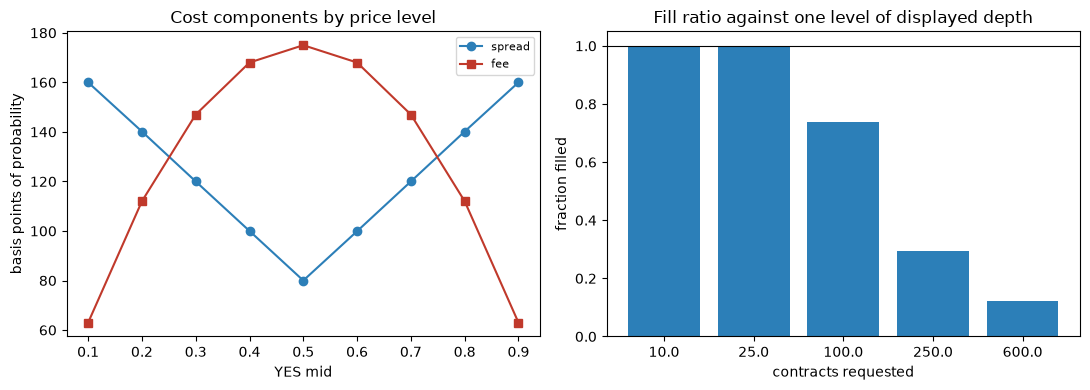

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(by_level.index, by_level.spread_bp, marker="o", color="#2c7fb8", label="spread")
axes[0].plot(
    by_level.index,
    [FEE_RATE * p * (1 - p) * 10_000 for p in by_level.index],
    marker="s",
    color="#c0392b",
    label="fee",
)
axes[0].set_title("Cost components by price level")
axes[0].set_xlabel("YES mid")
axes[0].set_ylabel("basis points of probability")
axes[0].legend(fontsize=8)
axes[1].bar(depth.requested.astype(str), depth.fill_ratio, color="#2c7fb8")
axes[1].axhline(1.0, color="black", lw=0.8)
axes[1].set_title("Fill ratio against one level of displayed depth")
axes[1].set_xlabel("contracts requested")
axes[1].set_ylabel("fraction filled")
fig.tight_layout()

## Takeaways

- Microprice and imbalance are computable from a single snapshot, so they are
  the microstructure signals snapshot data actually supports.
- A queue-position claim is not. `backtest.inspect` reports
  `unsupported_queue_claim` and `execute` refuses, so the limit is enforced
  rather than documented.
- Check order size against displayed depth. One level per side means a large
  order is cancelled, not filled at a worse price, and a backtest that never
  looks will silently assume liquidity it never had.
- `slippage_ticks` and `queue_position` are mutually exclusive by construction.
  Run them as scenarios, not as a grid.
- h5i-db features doing the work: `ReplayFidelity` naming what the data
  supports, preflight refusing a claim it cannot support, and one pinned
  snapshot behind every scenario so the only thing varying is the execution
  assumption.

In [12]:
db.close()